# Maximum Dissimilarity Algorithm (MDA)

This independent notebook demonstrates how **MDA** selects a compact and diverse subset from a random dataset using `bluemath_tk`. No LHS data are used.

## 1. Method

MDA is a greedy representative-selection algorithm. After choosing an initial point, it repeatedly adds the candidate whose minimum distance to the selected set is largest:

$$x_{k+1}=\underset{x\in\mathcal{D}}{\operatorname{argmax}}\;\min_{c\in\mathcal{C}_k}d(x,c).$$

Here, $\mathcal{D}$ is the complete dataset and $\mathcal{C}_k$ contains the $k$ selected centroids. The procedure tends to retain boundaries and extremes while distributing the selected points across the domain.

In [1]:
import numpy as np
import pandas as pd

from bluemath_tk.datamining.mda import MDA
from utils.plotting import plot_variable_combinations

## 2. Generate an independent random dataset

A seeded random generator creates 5,000 synthetic sea states. The variables deliberately have different scales, allowing the example to show how MDA covers a multidimensional domain. `Dir` is circular and must be declared as directional during fitting.

In [2]:
rng = np.random.default_rng(seed=0)
num_samples = 5000

data = pd.DataFrame(
    {
        "Hs": rng.uniform(0, 7, num_samples),
        "Tp": rng.uniform(3, 20, num_samples),
        "Dir": rng.uniform(0, 360, num_samples),
    }
)
data

,Hs,Tp,Dir
0,4.458732,18.048472,204.482489
1,1.888507,14.740973,346.494984
2,0.286815,11.194120,275.833857
3,0.115693,14.551638,299.927614
4,5.692892,17.207899,204.996538
...,...,...,...
4995,6.855727,10.821839,164.581170
4996,2.990053,15.485029,102.178326
4997,5.728659,6.153840,244.479507
4998,0.628854,18.905363,98.533010


## 3. Select representative centroids

The model selects 100 cases from the 5,000 candidates. Direction is treated with circular distance, so values near $0^\circ$ and $360^\circ$ are correctly recognized as neighbors.

### Arguments used

**When creating `MDA`:**

- `num_centers`: number of representative cases to retain. A larger value represents the original cloud more closely but requires more downstream simulations.

**In `fit_predict`:**

- `data`: complete candidate `DataFrame`. Its numeric columns define the space in which dissimilarity is evaluated.
- `directional_variables`: columns containing circular values in degrees. Listing `Dir` prevents $1^\circ$ and $359^\circ$ from being treated as far apart. Use `[]` when every variable is linear.

Useful optional arguments are `first_centroid_seed`, which fixes the starting row, and `normalize_data` together with `custom_scale_factor`, which allows explicit scaling ranges. If no first seed is supplied, the maximum-value centroid is used initially.

The method returns an array with the nearest-centroid index for each input row and a `DataFrame` with those nearest centroid values. The selected unique cases are stored in `mda.centroids`.

In [3]:
num_centers = 100
directional_variables = ["Dir"]

mda = MDA(num_centers=num_centers)
nearest_centroids_idxs, nearest_centroids_df = mda.fit_predict(
    data=data,
    directional_variables=directional_variables,
)
mda.centroids

,Hs,Tp,Dir_u,Dir_v,Dir
0,6.179176,19.933003,0.677201,0.735798,42.625283
1,0.228006,3.067367,0.126364,0.991984,7.259543
2,6.880769,10.276960,-0.976156,-0.217072,257.462888
3,0.034487,14.622381,-0.903056,0.429523,295.437272
4,6.808402,3.291880,-0.917666,-0.397352,246.587275
...,...,...,...,...,...
95,0.592239,18.098355,0.904243,0.427019,64.721474
96,3.274720,12.268678,-0.979213,-0.202837,258.297095
97,6.676479,17.529186,-0.357861,-0.933775,200.968887
98,3.791995,4.872686,-0.863026,-0.505159,239.658077


## 4. Inspect the selection

The checks below confirm the requested reduction and display the nearest representative case for the first observations. The pairwise plots compare the complete random cloud with the selected MDA centroids.

In [4]:
print(f"Original cases: {len(data):,}")
print(f"Selected centroids: {len(mda.centroids):,}")
nearest_centroids_df.head()

Original cases: 5,000
Selected centroids: 100


,Hs,Tp,Dir_u,Dir_v,Dir
24,5.203568,17.960731,0.561652,-0.827373,145.829851
21,2.508730,16.133512,0.423034,0.906114,25.026307
28,0.239063,10.303428,-0.834903,0.550397,303.394226
3,0.034487,14.622381,-0.903056,0.429523,295.437272
97,6.676479,17.529186,-0.357861,-0.933775,200.968887


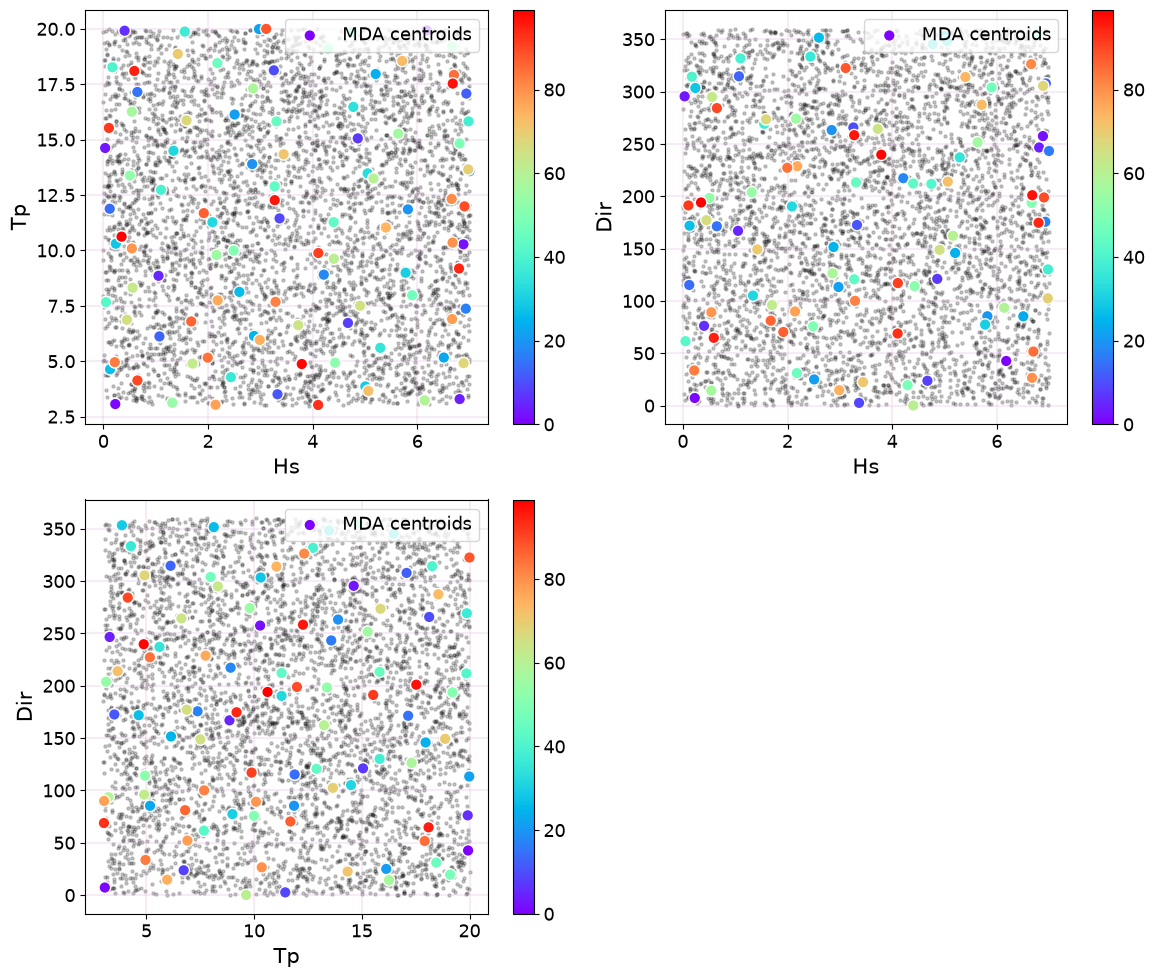

In [5]:
variables = ["Hs", "Tp", "Dir"]
plot_variable_combinations(
    data,
    variables,
    mda.centroids,
    labels="MDA centroids",
)

## Interpretation

A good MDA subset spans the same domain as the original cloud, including sparsely populated edges, with far fewer cases. MDA is therefore useful when evaluating every candidate is expensive and only a limited number of simulations or observations can be retained. It prioritizes diversity rather than reproducing the probability density of the source sample.

## Summary

MDA reduced 5,000 independently generated random cases to 100 representative centroids. The result can be passed to a numerical model or used as the training subset for an interpolation method such as RBF.